# K nearest neighboar

este tipo de modelos ayuda a predecir valores que se puedan calcular con los valores que puede haber con los de entrenamiento,
en este caso este modelo se logra ver que tiene varios problemas y uno es que como se basa con los vecinos mas cercanos 
entonces en los casos a futuros lo mas probable es que como no tiene valores cercanos esto puede afectr en la predicion de los modelos

## Metodo largo

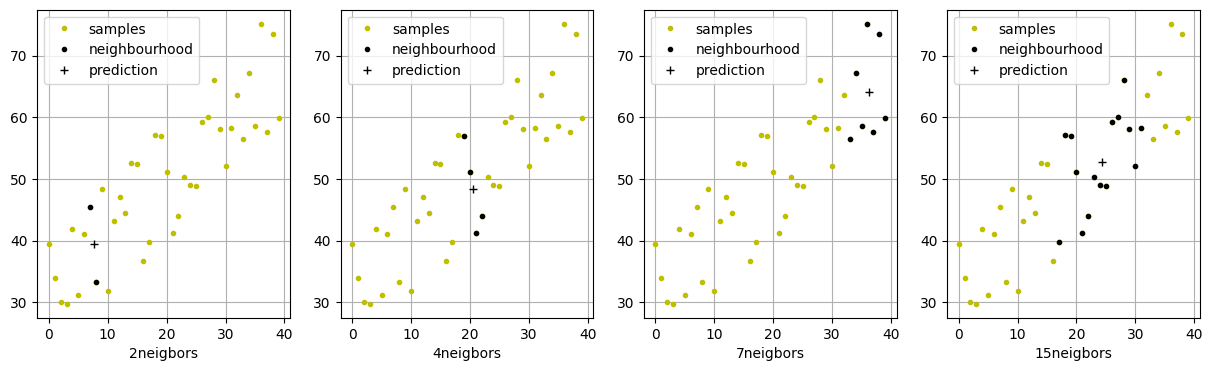

In [1]:
import matplotlib.pyplot as plt
import random 


X = list(range(40))
y = []

for i in range(len(X)):
    y.append(20 + X[i] + random.random()*20)

fig, axs = plt.subplots(1,4, figsize=(15,4))

def KNN_predict(k, X, y, x,figure):
    distance = []
    for i in range(len(X)):
        distance.append((X[i],y[i],(x-X[i])**2))
    
    sorted_list = sort(distance)
    
    x_neighbourhood, y_neighbourhood = [],[]

    y_prediction = 0.0

    for i in range(k):
        y_prediction += sorted_list[i][1]
        x_neighbourhood.append(sorted_list[i][0])
        y_neighbourhood.append(sorted_list[i][1])
    
    y_prediction /= k

    plot(figure,X,y,'y.',"samples")
    
    plot(figure,x_neighbourhood,y_neighbourhood,'k.',"neighbourhood")

    plot(figure,x,y_prediction,'k+',"prediction")

    axs[figure].set_xlabel('{:1.0f}'.format(k) + 'neigbors')

    return y_prediction


def sort(unsorted_list):
    return (sorted(unsorted_list,key=lambda x: x[2]))

def plot(fig,X,y,paramsters, label):
    axs[fig].plot(X,y,paramsters,label=label)
    axs[fig].legend(); axs[fig].grid()
    return

KNN_predict(2 ,X , y, 7.6, 0)
KNN_predict(4,X,y,20.5,1)
KNN_predict(7,X,y,36.2,2)
KNN_predict(15,X,y,24.3,3)

plt.show()
        


## knn with scikit

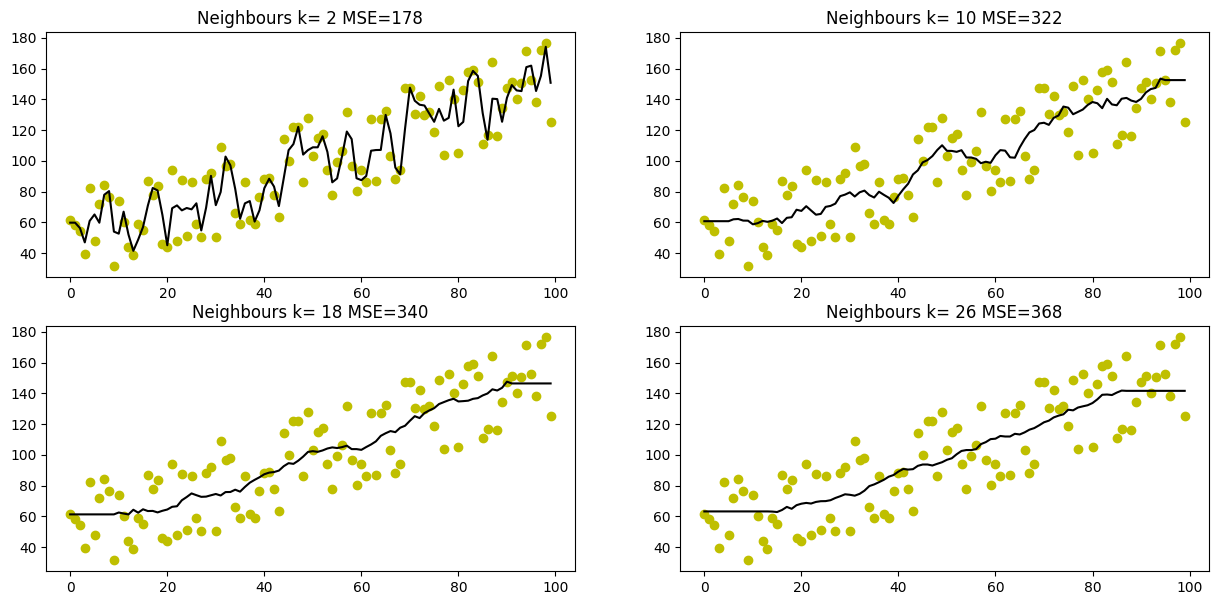

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import neighbors
from sklearn.metrics import mean_squared_error
import random


X = np.array(list(range(100)))[:, np.newaxis]

y = []

for i in range(len(X)):
    y.append(20 + X[i]+random.random()*60)


fig, axs = plt.subplots(2,2,figsize=(15,7))

for i, n_neighbors in zip([0,1,2,3],[2,10,18,26]):
    knn_regression = neighbors.KNeighborsRegressor(n_neighbors)

    knn_model = knn_regression.fit(X,y)

    # la idea no es usar la muestra para entrenar y predecir pero esto es solo un ejemplo
    y_prediction = knn_model.predict(X)

    MSE = mean_squared_error(y,y_prediction)

    axs[int(i/2), i%2].scatter(X,y, c='y')
    axs[int(i/2), i%2].plot(X,y_prediction, c='k')
    axs[int(i/2), i%2].set_title('Neighbours k= '+ str(n_neighbors) + ' MSE={:1.0f}'.format(MSE))
    


plt.show()

